In [2]:
# ⚙️ Initial Setup - Run this first
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
from collections import Counter
import re
import warnings
import zipfile
import requests
from pathlib import Path
import time
warnings.filterwarnings('ignore')

# For reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("✅ Imports loaded successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create data directory
Path("../data/imdb").mkdir(parents=True, exist_ok=True)

✅ Imports loaded successfully!
PyTorch version: 2.10.0+cu128
GPU available: True
Using device: cuda


In [3]:
class Vocabulary:
    """Build vocabulary from text data
    
    This class handles the mapping between words and indices.
    It's a fundamental building block for any NLP project.
    """
    def __init__(self, min_freq=5):
        # Special tokens get indices 0 and 1
        self.word2idx = {'<PAD>': 0, '<UNK>': 1}
        self.idx2word = {0: '<PAD>', 1: '<UNK>'}
        self.min_freq = min_freq
        self.word_counts = {}
    
    def build_vocab(self, texts):
        """Build vocabulary from list of texts"""
        print("Building vocabulary...")
        
        # First pass: count all words
        for text in texts:
            # Simple tokenization - split on whitespace
            for word in text.lower().split():
                # Remove punctuation for cleaner vocabulary
                word = re.sub(r'[^\w\s]', '', word)
                if word:  # Skip empty strings
                    self.word_counts[word] = self.word_counts.get(word, 0) + 1
        
        print(f"  Found {len(self.word_counts):,} unique words")
        
        # Second pass: add words that meet minimum frequency
        words_added = 0
        for word, count in self.word_counts.items():
            if count >= self.min_freq:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word
                words_added += 1
        
        print(f"  Words meeting min_freq={self.min_freq}: {words_added:,}")
        print(f"  Words discarded (rare): {len(self.word_counts) - words_added:,}")
        
        # Calculate coverage - what % of words in text are in vocabulary?
        total_words = sum(self.word_counts.values())
        covered_words = sum(count for word, count in self.word_counts.items() 
                           if word in self.word2idx)
        coverage = covered_words / total_words * 100
        print(f"  Coverage of training text: {coverage:.1f}%")
        
        return self
    
    def encode(self, text):
        """Convert text to list of indices"""
        tokens = []
        for word in text.lower().split():
            word = re.sub(r'[^\w\s]', '', word)
            if word:  # Skip empty strings
                idx = self.word2idx.get(word, self.word2idx['<UNK>'])
                tokens.append(idx)
        return tokens
    
    def decode(self, indices):
        """Convert indices back to text (for debugging)"""
        words = []
        for idx in indices:
            word = self.idx2word.get(idx, '<UNK>')
            words.append(word)
        return ' '.join(words)

# Let's test it with some sample data
sample_texts = [
    "I loved this movie it was fantastic",
    "This film was terrible I hated it",
    "Amazing acting and great story",
    "Boring and predictable waste of time",
    "One of the best movies I've ever seen",
    "Worst film of the year complete garbage"
] * 50  # Repeat to simulate more data

vocab = Vocabulary(min_freq=2).build_vocab(sample_texts)
print(f"\n📊 Final vocabulary size: {len(vocab.word2idx)}")

Building vocabulary...
  Found 31 unique words
  Words meeting min_freq=2: 31
  Words discarded (rare): 0
  Coverage of training text: 100.0%

📊 Final vocabulary size: 33


In [4]:
print("="*60)
print("THE OOV PROBLEM DEMONSTRATION")
print("="*60)

test_words = [
    "cinematography",  # Common in reviews but might be rare
    "masterpiece",     # Common positive word
    "abysmal",         # Common negative word
    "xylophone",       # Rare, likely OOV
    "quintessentially",# Rare, likely OOV
    "the",             # Very common, should be in vocab
    "movie",           # Very common, should be in vocab
    "fantastic",       # Should be in vocab from our samples
    "terrible"         # Should be in vocab from our samples
]

print("\n🔍 Testing vocabulary coverage:")
print("-" * 60)
for word in test_words:
    indices = vocab.encode(word)
    idx = indices[0] if indices else vocab.word2idx['<UNK>']
    status = "✅ IN vocabulary" if idx != 1 else "❌ OOV (unknown)"
    print(f"  '{word}': index {idx} - {status}")

print("\n⚠️ The OOV Problem:")
print("  • Common words like 'cinematography' might be missing")
print("  • Rare but meaningful words become <UNK>")
print("  • We lose information!")
print("\n💡 This is why modern NLP uses subword tokenization (BPE):")
print("   'cinematography' → ['cine', 'mat', 'ography'] (all known pieces!)")

THE OOV PROBLEM DEMONSTRATION

🔍 Testing vocabulary coverage:
------------------------------------------------------------
  'cinematography': index 1 - ❌ OOV (unknown)
  'masterpiece': index 1 - ❌ OOV (unknown)
  'abysmal': index 1 - ❌ OOV (unknown)
  'xylophone': index 1 - ❌ OOV (unknown)
  'quintessentially': index 1 - ❌ OOV (unknown)
  'the': index 23 - ✅ IN vocabulary
  'movie': index 5 - ✅ IN vocabulary
  'fantastic': index 8 - ✅ IN vocabulary
  'terrible': index 10 - ✅ IN vocabulary

⚠️ The OOV Problem:
  • Common words like 'cinematography' might be missing
  • Rare but meaningful words become <UNK>
  • We lose information!

💡 This is why modern NLP uses subword tokenization (BPE):
   'cinematography' → ['cine', 'mat', 'ography'] (all known pieces!)


In [5]:
print("="*60)
print("UNDERSTANDING EMBEDDINGS")
print("="*60)

# Create a simple embedding layer
vocab_size = 10  # Small vocabulary for demonstration
embedding_dim = 5  # Small dimension so we can see the numbers
embedding = nn.Embedding(vocab_size, embedding_dim)

print(f"Embedding layer: {vocab_size} words × {embedding_dim} dimensions")
print(f"Weight matrix shape: {embedding.weight.shape}")
print(f"Total parameters: {vocab_size * embedding_dim} learnable numbers")
print("\nEmbedding weights (randomly initialized):")
print(embedding.weight.data)

# Look up embeddings for specific words
word_indices = torch.tensor([2, 5, 2])  # Look up words 2, 5, and 2 again
word_vectors = embedding(word_indices)

print(f"\nLooking up indices {word_indices.tolist()}:")
print(f"Output shape: {word_vectors.shape}")
print("Word vectors:")
print(word_vectors)
print("\nNote: Same index (2) gives SAME vector - that's the lookup table!")

UNDERSTANDING EMBEDDINGS
Embedding layer: 10 words × 5 dimensions
Weight matrix shape: torch.Size([10, 5])
Total parameters: 50 learnable numbers

Embedding weights (randomly initialized):
tensor([[ 1.9269,  1.4873,  0.9007, -2.1055,  0.6784],
        [-1.2345, -0.0431, -1.6047, -0.7521,  1.6487],
        [-0.3925, -1.4036, -0.7279, -0.5594, -0.7688],
        [ 0.7624,  1.6423, -0.1596, -0.4974,  0.4396],
        [-0.7581,  1.0783,  0.8008,  1.6806,  1.2791],
        [ 1.2964,  0.6105,  1.3347, -0.2316,  0.0418],
        [-0.2516,  0.8599, -1.3847, -0.8712,  0.0780],
        [ 0.5258, -0.4880,  1.1914, -0.8140, -0.7360],
        [-0.8371, -0.9224, -0.0635,  0.6756, -0.0978],
        [ 1.8446, -1.1845,  1.3835, -1.2024,  0.7078]])

Looking up indices [2, 5, 2]:
Output shape: torch.Size([3, 5])
Word vectors:
tensor([[-0.3925, -1.4036, -0.7279, -0.5594, -0.7688],
        [ 1.2964,  0.6105,  1.3347, -0.2316,  0.0418],
        [-0.3925, -1.4036, -0.7279, -0.5594, -0.7688]],
       grad_fn=<

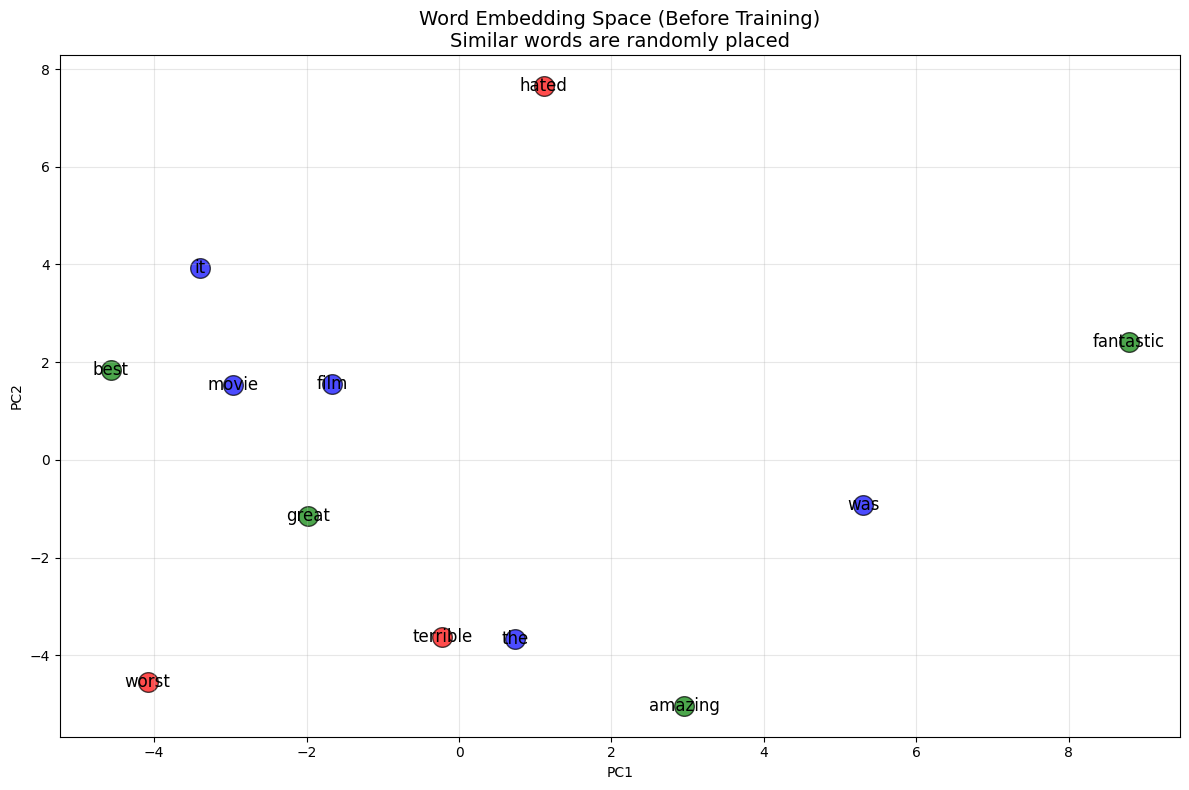


🎯 Key Insight:
   • Initially, embeddings are RANDOM
   • Similar words are NOT necessarily close
   • During training, the model will learn to push
     similar words together and different words apart!

✅ Was your prediction correct? The words are randomly scattered!


In [6]:
def visualize_embedding_space(emb_layer, words, word2idx):
    """Visualize that similar words should cluster together"""
    from sklearn.decomposition import PCA
    
    # Get embeddings for available words
    indices = []
    available_words = []
    for word in words:
        if word in word2idx:
            indices.append(word2idx[word])
            available_words.append(word)
    
    if not indices:
        print("No words found in vocabulary")
        return
    
    # Get embeddings
    embeddings = emb_layer(torch.tensor(indices)).detach().numpy()
    
    # Reduce to 2D for visualization
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings)
    
    # Plot
    plt.figure(figsize=(12, 8))
    
    # Define word groups for coloring
    positive_words = ['good', 'great', 'excellent', 'fantastic', 'amazing', 'wonderful', 'best', 'loved']
    negative_words = ['bad', 'terrible', 'awful', 'horrible', 'worst', 'hated', 'garbage']
    neutral_words = ['movie', 'film', 'the', 'was', 'it', 'this']
    
    # Color by sentiment group
    for i, word in enumerate(available_words):
        if word in positive_words:
            color = 'green'
        elif word in negative_words:
            color = 'red'
        else:
            color = 'blue'
        
        plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], 
                   c=color, s=200, alpha=0.7, edgecolors='black')
        plt.annotate(word, (embeddings_2d[i, 0], embeddings_2d[i, 1]), 
                    fontsize=12, ha='center', va='center')
    
    plt.title("Word Embedding Space (Before Training)\nSimilar words are randomly placed", 
              fontsize=14)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\n🎯 Key Insight:")
    print("   • Initially, embeddings are RANDOM")
    print("   • Similar words are NOT necessarily close")
    print("   • During training, the model will learn to push")
    print("     similar words together and different words apart!")
    
# Test with random embeddings
test_words = ['good', 'great', 'excellent', 'best', 'fantastic', 'amazing',
              'bad', 'terrible', 'awful', 'worst', 'hated',
              'movie', 'film', 'the', 'was', 'it']

# Create a larger embedding layer for visualization
emb_layer = nn.Embedding(len(vocab.word2idx), 128)
visualize_embedding_space(emb_layer, test_words, vocab.word2idx)

print("\n✅ Was your prediction correct? The words are randomly scattered!")

# 🔧 PART 5: Building an RNN from Scratch

Now we get to the heart of sequence modeling: the Recurrent Neural Network.

## The Core Idea: Memory Through Recurrence

An RNN has one key innovation over a regular neural network: **a loop** that allows information to persist.

```
Feedforward Network (no memory):
    x₁ ──→ [Network] ──→ y₁
    x₂ ──→ [Network] ──→ y₂  (independent predictions)
    (Each input processed in isolation)

Recurrent Network (with memory):
    x₁ ──→ [Network] ──→ y₁
             ↑
           h₀ (initial memory of zeros)
    
    x₂ ──→ [Network] ──→ y₂
             ↑
           h₁ (memory from step 1)
    
    x₃ ──→ [Network] ──→ y₃
             ↑
           h₂ (memory from steps 1-2)
```

<div align="center">
  <img src="assets/rnn.png" width="600" alt="RNN Architecture">
</div>

## The Mathematical Formulation

At each time step t, the RNN does:

**1. Update hidden state (memory):**
$$h_t = \tanh(W_{ih} x_t + b_{ih} + W_{hh} h_{t-1} + b_{hh})$$

**2. Produce output (if needed):**
$$y_t = W_{hy} h_t + b_y$$

Let's break this down:
- $x_t$: Current input (e.g., word embedding at time t)
- $h_{t-1}$: Previous hidden state (memory of past)
- $W_{ih}$: Input-to-hidden weights (process current word)
- $W_{hh}$: Hidden-to-hidden weights (transform past memory)
- $\tanh$: Activation function that squashes values to [-1, 1]

### 🧠 Mental Model: The Reader with a Scratch Pad

```
Reading a review word by word:

Time t=1: Read "I" 
    → Write on scratch pad: [0.1, 0.2, -0.3, ...]
    (initial impression - just starting)

Time t=2: Read "loved"  
    → Update scratch pad: [0.3, 0.8, -0.1, ...]
    (now we know sentiment is positive!)

Time t=3: Read "this"  
    → Update scratch pad: [0.3, 0.8, -0.1, ...]
    (minor word, memory mostly unchanged)

Time t=4: Read "movie"  
    → Update scratch pad: [0.3, 0.8, 0.2, ...]
    (now we know the topic)

Final scratch pad (h₄) contains a summary of the entire review!
```

## Building an RNN Cell from Scratch

Let's implement the core RNN computation to really understand what's happening:

In [9]:
class SimpleRNNCell(nn.Module):
    """A single RNN cell - built from scratch to understand the math
    
    This implements exactly the equation:
    h_t = tanh(W_ih @ x_t + b_ih + W_hh @ h_{t-1} + b_hh)
    """
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        
        # Weight matrices for input-to-hidden and hidden-to-hidden
        # These are the W_ih and W_hh from the equation
        self.W_ih = nn.Linear(input_size, hidden_size)
        self.W_hh = nn.Linear(hidden_size, hidden_size)
        
        print(f"  RNN Cell: input {input_size} → hidden {hidden_size}")
        print(f"  Parameters: {input_size*hidden_size + hidden_size*hidden_size:,}")
        
    def forward(self, x, hidden):
        """
        x: (batch_size, input_size) - current word embedding
        hidden: (batch_size, hidden_size) - previous hidden state
        """
        # The core RNN equation: h_t = tanh(W_ih·x_t + W_hh·h_{t-1})
        combined = self.W_ih(x) + self.W_hh(hidden)
        hidden = torch.tanh(combined)
        return hidden
    
    def init_hidden(self, batch_size):
        """Initialize hidden state to zeros"""
        return torch.zeros(batch_size, self.hidden_size)

# Let's create and test our cell
print("="*60)
print("BUILDING RNN CELL FROM SCRATCH")
print("="*60)

# Create cell
cell = SimpleRNNCell(input_size=100, hidden_size=256)
hidden = cell.init_hidden(batch_size=1)

# Simulate reading a sentence word by word
sentence = ["the", "movie", "was", "absolutely", "fantastic"]
print(f"\nReading sentence: {' → '.join(sentence)}")
print("-" * 50)

for i, word in enumerate(sentence):
    # In reality, this would be a learned embedding
    # For demo, we use random vector
    x = torch.randn(1, 100)
    
    # Update hidden state
    hidden = cell(x, hidden)
    
    # Track statistics to see how hidden state evolves
    norm = hidden.norm().item()
    mean = hidden.mean().item()
    std = hidden.std().item()
    
    print(f"  Step {i+1} ({word:10}): |h|={norm:.2f}, μ={mean:.2f}, σ={std:.2f}")

print("\n💡 After reading the whole sentence, the hidden state")
print("   contains a 'summary' that we can use for classification!")

BUILDING RNN CELL FROM SCRATCH
  RNN Cell: input 100 → hidden 256
  Parameters: 91,136

Reading sentence: the → movie → was → absolutely → fantastic
--------------------------------------------------
  Step 1 (the       ): |h|=7.34, μ=-0.01, σ=0.46
  Step 2 (movie     ): |h|=8.14, μ=0.01, σ=0.51
  Step 3 (was       ): |h|=8.15, μ=0.04, σ=0.51
  Step 4 (absolutely): |h|=7.93, μ=-0.02, σ=0.50
  Step 5 (fantastic ): |h|=8.40, μ=-0.03, σ=0.53

💡 After reading the whole sentence, the hidden state
   contains a 'summary' that we can use for classification!


In [10]:
class RNNClassifier(nn.Module):
    """Complete RNN for sentiment classification
    
    This uses PyTorch's built-in RNN for efficiency,
    but now you understand exactly what's happening inside!
    """
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_classes, 
                 num_layers=1, dropout=0.3):
        super().__init__()
        
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # 1. Embedding layer (numbers → meaning)
        # This converts word indices to dense vectors
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # 2. RNN layer (process sequence)
        # This implements the recurrence we just built manually
        self.rnn = nn.RNN(embedding_dim, hidden_size, num_layers,
                          batch_first=True, dropout=dropout if num_layers > 1 else 0)
        
        # 3. Dropout (regularization to prevent overfitting)
        self.dropout = nn.Dropout(dropout)
        
        # 4. Classifier (hidden state → prediction)
        self.fc = nn.Linear(hidden_size, num_classes)
        
        print(f"✅ RNN Classifier built:")
        print(f"   Vocab size: {vocab_size:,}")
        print(f"   Embedding dim: {embedding_dim}")
        print(f"   Hidden size: {hidden_size}")
        print(f"   Layers: {num_layers}")
        
    def forward(self, x):
        """
        x: (batch_size, seq_len) - word indices
        """
        batch_size = x.shape[0]
        
        # 1. Get embeddings
        # Shape: (batch_size, seq_len) → (batch_size, seq_len, embedding_dim)
        embedded = self.embedding(x)
        embedded = self.dropout(embedded)
        
        # 2. Initialize hidden state to zeros
        # Shape: (num_layers, batch_size, hidden_size)
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        
        # 3. Forward through RNN
        # output: (batch_size, seq_len, hidden_size) - all hidden states
        # hidden: (num_layers, batch_size, hidden_size) - last hidden state
        output, hidden = self.rnn(embedded, h0)
        
        # 4. Take the last layer's hidden state for classification
        # hidden[-1] gives the last layer's final hidden state
        last_hidden = hidden[-1]  # Shape: (batch_size, hidden_size)
        
        # 5. Classify
        out = self.dropout(last_hidden)
        out = self.fc(out)  # Shape: (batch_size, num_classes)
        
        return out

# Test the model
print("\n🧪 Testing RNN forward pass:")
model_rnn = RNNClassifier(vocab_size=len(vocab.word2idx), 
                          embedding_dim=100, 
                          hidden_size=256, 
                          num_classes=2)

# Create dummy batch (4 reviews, each 50 words)
dummy_batch = torch.randint(0, len(vocab.word2idx), (4, 50))
output = model_rnn(dummy_batch)
print(f"\nInput shape: {dummy_batch.shape}")
print(f"Output shape: {output.shape}")  # Should be (4, 2) - logits for pos/neg


🧪 Testing RNN forward pass:
✅ RNN Classifier built:
   Vocab size: 33
   Embedding dim: 100
   Hidden size: 256
   Layers: 1

Input shape: torch.Size([4, 50])
Output shape: torch.Size([4, 2])


In [ ]:
class IMDBDataset(Dataset):

    def __init__(self, texts, labels, vocab, max_length):

        self.texts = texts 
        self.labels = labels
        self.vocab = vocab 
        self.max_length = max_length 

    def __len__(self):
        return len(self.texts) 

    def __getitem__(self, idx):

        text = self.texts[idx]
        label = self.labels[idx] 

        incides = self.vocab.encode(
            text , 
            self.max_length
        )

        return torch.tensor(incides, dtype=torch.long) , torch.tensor(label, dtype=torch.tensor) 

def collate_batch(batch):

    texts , labels = zip(*batch)

    lengths = torch.tensor([len(text)] for text in texts)

    text_padded = torch.nn.utils.rnn.pad_sequence(
        texts,
        batch_first=True,
        padding_value=0
    )

    return text_padded , torch.tensor(labels) , lengths 


train_dataset  = IMDBDataset(train_texts , train_labels , vocab, max_length=500)
train_dataset  = IMDBDataset(val_texts , val_labels , vocab, max_length=500)


batch_size = 64 

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size, 
    shuffle=True,
    collate_fn=collate_batch,
    num_workers=2
)